In [1]:
# Bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist # Carregar os dados
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() # Separar em treino e teste
x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalizar os dados
print("x_train.shape: ", x_train.shape)

x_train.shape:  (60000, 28, 28)


In [3]:
x_train = np.expand_dims(x_train, -1) # adicionando uma dimensão no final
x_test = np.expand_dims(x_test, -1) # adicionando uma dimensão no final
print("x_train.shape: ", x_train.shape) # é usado o shape para visualizar a nova dimensão

x_train.shape:  (60000, 28, 28, 1)


In [4]:
k = len(set(y_train)) # número de classes
print("Número de classes: ", k)

Número de classes:  10


In [5]:
# Criando o modelo
i = Input(shape=x_train[0].shape)
# tres camadas de convolução
x = Conv2D(32, (3,3), strides=2, activation='relu') (i)
x = Conv2D(64, (3,3), strides=2, activation='relu') (x)
x = Conv2D(128, (3,3), strides=2, activation='relu') (x)

x = Flatten() (x) # transforma em um vetor
x = Dropout(0.2) (x)

x = Dense(512, activation='relu') (x)
x = Dropout(0.2) (x)
x = Dense(k, activation='softmax') (x)

model = Model (i,x)

In [6]:
# Compilando o modelo
model.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data= (x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.8073 - loss: 0.5208 - val_accuracy: 0.8419 - val_loss: 0.4187
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8640 - loss: 0.3645 - val_accuracy: 0.8712 - val_loss: 0.3506
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8811 - loss: 0.3130 - val_accuracy: 0.8822 - val_loss: 0.3175
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.8943 - loss: 0.2801 - val_accuracy: 0.8920 - val_loss: 0.3023
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9057 - loss: 0.2546 - val_accuracy: 0.8887 - val_loss: 0.2998
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9115 - loss: 0.2326 - val_accuracy: 0.8931 - val_loss: 0.2926
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9172 - loss: 0.2171 - val_accuracy: 0.8946 - val_loss: 0.2986
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9224 -

In [6]:
# grafico interativo do loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

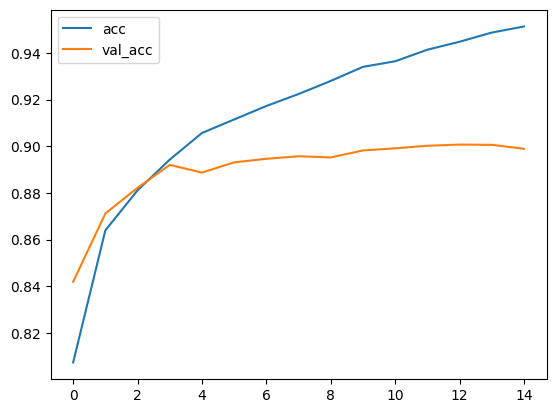

In [7]:
# grafico interativo da accuracia
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion matrix, without normalization
[[847   4  32  20   2   3  81   0  11   0]
 [  4 976   1  14   2   0   1   0   2   0]
 [ 13   1 865   7  49   0  63   0   2   0]
 [ 13   3  28 913  16   1  26   0   0   0]
 [  1   1  70  27 822   0  76   0   3   0]
 [  0   0   0   0   0 976   0  17   2   5]
 [126   0  92  22  61   1 686   0  12   0]
 [  0   0   0   0   0  12   0 969   0  19]
 [  2   1   5   3   3   1   4   2 977   2]
 [  1   0   0   0   0   5   0  35   1 958]]


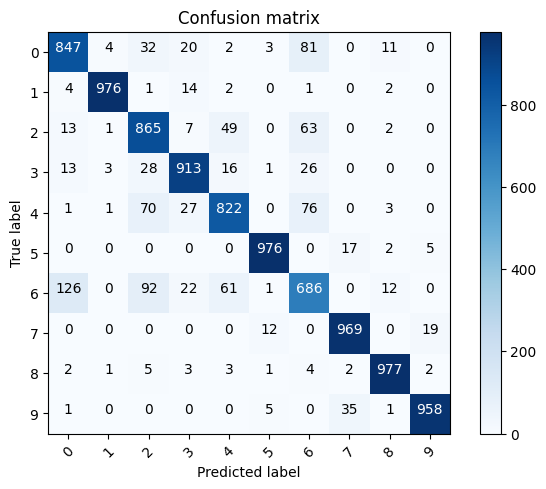

In [8]:
from sklearn.metrics import confusion_matrix # matriz de confusão
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # Cor
                          ):

    if normalize: # normalização da matriz
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plotagem da matriz de confusão
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title) # titulo
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x
    plt.yticks(tick_marks, classes) # rotulos do eixo y

    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto

    # adicionando texto na matriz de confusão
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # adicionando rótulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [9]:
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split()

Text(0.5, 1.0, 'True label: Pullover Predicted: Coat')

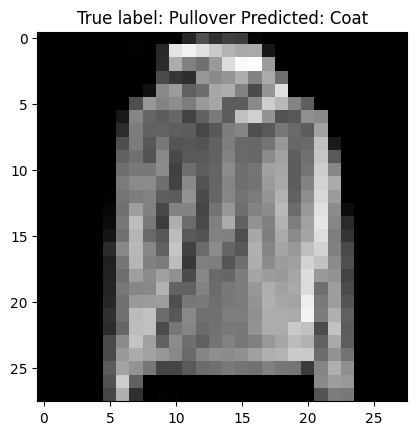

In [10]:
# É mostrado a imagem da classificacao incoreta
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]))
